In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [80]:

df = pd.read_csv("/content/drive/MyDrive/car_rent project/UrbanRideRentalsDirty_10k.csv")



In [81]:
df.columns = df.columns.str.lower().str.strip()

In [82]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

In [95]:
def clean_numeric(col):
    return pd.to_numeric(df[col].astype(str).str.replace(r'[^0-9.]','',regex=True), errors='coerce')

for col in ['fuelprice','marketingspend','avgdailytemp', 'rentedcars', 'availablecars', 'customerrating']:
    df[col] = clean_numeric(col)

df['isweekend'] = df['isweekend'].astype(str).str.lower().map({'yes':1,'no':0})
df['holidayflag'] = df['holidayflag'].astype(str).str.lower().map({'yes':1,'no':0})

# Removed fillna from here. It will be moved to a later stage after feature engineering.

if 'branchcity' in df.columns:
    df['branchcity'] = df['branchcity'].astype(str).str.lower().str.strip()
if 'promotiontype' in df.columns:
    df['promotiontype'] = df['promotiontype'].astype(str).str.lower().str.strip()

In [96]:
df = df.sort_values('date')

In [97]:
df['dayofweek'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

# Lag features
df['lag1'] = df['rentedcars'].shift(1)
df['lag2'] = df['rentedcars'].shift(2)
# df['lag3'] = df['rentedcars'].shift(3)
df['lag7'] = df['rentedcars'].shift(7)
# df['lag14'] = df['rentedcars'].shift(14)
# df['lag30'] = df['rentedcars'].shift(30)

In [98]:
df['rolling_mean_3'] = df['rentedcars'].shift(1).rolling(3).mean()
df['rolling_mean_7'] = df['rentedcars'].shift(1).rolling(7).mean()
# df['rolling_std_7'] = df['rentedcars'].shift(1).rolling(7).std()
# df['rolling_mean_2'] = df['rentedcars'].shift(1).rolling(2).mean()
# df['rolling_mean_4'] = df['rentedcars'].shift(1).rolling(4).mean()

In [99]:
q1 = df['rentedcars'].quantile(0.25)
q3 = df['rentedcars'].quantile(0.75)
iqr = q3 - q1

df = df[(df['rentedcars'] > q1 - 1.5*iqr) & (df['rentedcars'] < q3 + 1.5*iqr)]


In [100]:
columns_to_encode = ['branchcity', 'promotiontype']
existing_columns_to_encode = [col for col in columns_to_encode if col in df.columns]

if existing_columns_to_encode:
    df = pd.get_dummies(df, columns=existing_columns_to_encode, drop_first=True)

In [ ]:
# Fill missing values in numeric columns with the median
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Fill missing values in object columns with 'None'
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna('None')

In [101]:
split = int(len(df) * 0.8)

train = df.iloc[:split]
test = df.iloc[split:]

X_train = train.drop(['rentedcars','date','rentalid'], axis=1)
y_train = train['rentedcars']

X_test = test.drop(['rentedcars','date','rentalid'], axis=1)
y_test = test['rentedcars']

In [102]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.07,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.07, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [103]:
preds = model.predict(X_test)

print("R2 Score:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))


R2 Score: 0.8450985910070878
MAE: 11.535559549541055
RMSE: 14.81116771744688


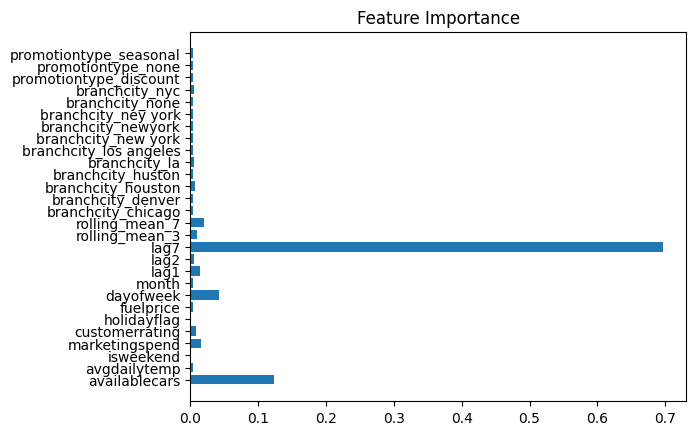

In [104]:
importance = model.feature_importances_
features = X_train.columns

plt.figure()
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

In [105]:
train_preds = model.predict(X_train)
print("Train R2:", r2_score(y_train, train_preds))

Train R2: 0.9688111868097471


In [106]:
preds = model.predict(X_test)

print("Test R2:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, preds)))

# Train score (check overfitting)
train_preds = model.predict(X_train)
print("Train R2:", r2_score(y_train, train_preds))

Test R2: 0.8450985910070878
MAE: 11.535559549541055
RMSE: 14.81116771744688
Train R2: 0.9688111868097471
